Experiment 6: Sequential Models – RNN, LSTM, GRU

In [1]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [2]:
#load imdb dataset
(x_train, y_train),(x_test,y_test) = tf.keras.datasets.imdb.load_data(num_words=10000)

#Pad sequences
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=100)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=100)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#Building RNN Model
model_rnn = models.Sequential([
    layers.Embedding(10000, 32, input_length=100),
    layers.SimpleRNN(32),
    layers.Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_rnn = model_rnn.fit(x_train, y_train, epochs=5, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.7042 - loss: 0.5477 - val_accuracy: 0.8108 - val_loss: 0.4323
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.8645 - loss: 0.3274 - val_accuracy: 0.8254 - val_loss: 0.4276
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9181 - loss: 0.2134 - val_accuracy: 0.8154 - val_loss: 0.4672
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9628 - loss: 0.1071 - val_accuracy: 0.8118 - val_loss: 0.5653
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9794 - loss: 0.0632 - val_accuracy: 0.7770 - val_loss: 0.6848


In [4]:
#LSTM Model
model_lstm = models.Sequential([
    layers.Embedding(10000,32,input_length=100),
    layers.LSTM(32),
    layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_lstm = model_lstm.fit(x_train, y_train,epochs=5,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.7862 - loss: 0.4372 - val_accuracy: 0.8410 - val_loss: 0.3552
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.8947 - loss: 0.2653 - val_accuracy: 0.8442 - val_loss: 0.3539
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9249 - loss: 0.1959 - val_accuracy: 0.8424 - val_loss: 0.3935
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9481 - loss: 0.1448 - val_accuracy: 0.8368 - val_loss: 0.4699
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9596 - loss: 0.1128 - val_accuracy: 0.8342 - val_loss: 0.5058


In [5]:
#GRU Model
model_gru = models.Sequential([
    layers.Embedding(10000, 32, input_length=100),
    layers.GRU(32),
    layers.Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_gru = model_gru.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.7685 - loss: 0.4632 - val_accuracy: 0.8256 - val_loss: 0.3926
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.8838 - loss: 0.2889 - val_accuracy: 0.8460 - val_loss: 0.3611
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9183 - loss: 0.2157 - val_accuracy: 0.8430 - val_loss: 0.3654
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.9409 - loss: 0.1632 - val_accuracy: 0.8430 - val_loss: 0.4449
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9606 - loss: 0.1161 - val_accuracy: 0.8376 - val_loss: 0.4723


In [6]:
print("RNN:", history_rnn.history['val_accuracy'][-1])
print("LSTM:", history_lstm.history['val_accuracy'][-1])
print("GRU:", history_gru.history['val_accuracy'][-1])

RNN: 0.7770000100135803
LSTM: 0.8342000246047974
GRU: 0.8375999927520752


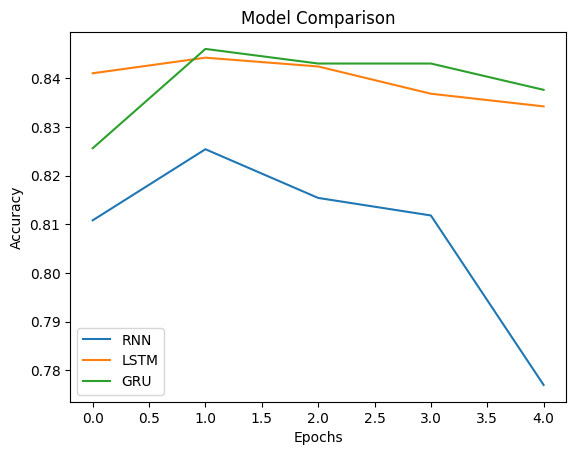

In [7]:
plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_gru.history['val_accuracy'], label='GRU')

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()